In [1]:
import pandas as pd 
import numpy as np
import torch 
import torch.nn as nn 

In [21]:
text = np.load('X_raw.npy')
labels = np.load ('y_raw.npy')
clean_text = np.load ('X_clean_raw.npy')
clean_labels = np.zeros(shape = (450,))

In [22]:
print(f'text shape : {text.shape}')
print ( f'labels shape : {labels.shape}')
print(f'text clean shape : {clean_text.shape}')
print ( f'labels clean shape : {clean_labels.shape}')

text shape : (450, 768)
labels shape : (450,)
text clean shape : (450, 768)
labels clean shape : (450,)


In [27]:
text = np.vstack((text, clean_text[:150]))
labels = np.concatenate((labels, clean_labels[:150]))
print("Kích thước text sau khi ghép:", text.shape)
print("Kích thước labels sau khi ghép:", labels.shape)

Kích thước text sau khi ghép: (600, 768)
Kích thước labels sau khi ghép: (600,)


In [28]:
label_type = []
for i in labels : 
    if i not in label_type : 
        label_type.append(i)
label_type
# 0 la clean | 1 la trigger | 2 la trigger 


[np.float64(0.0), np.float64(1.0), np.float64(2.0)]

In [29]:
#chuyen label 1 2 -> 1

new_labels = np.where(labels >=1 , 1, 0 )
new_labels


array([0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,

In [30]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif

def mutual_information_filtering(X, y, num_features=64):
    # X: ma trận (450, 768), y: nhãn (450,)
    # Tính toán điểm Mutual Information cho từng đặc trưng
    mi_scores = mutual_info_classif(X, y, random_state=42)
    
    # Lấy top 64 nơ-ron có điểm số cao nhất
    top_indices = np.argsort(mi_scores)[-num_features:]
    X_filtered = X[:, top_indices]
    
    return X_filtered, top_indices

X_64, top_idx = mutual_information_filtering(text, labels)
print (X_64)
print (top_idx)

[[ 0.01499903  0.01699521  0.02947411 ...  0.02367947  0.02798462
   0.02035554]
 [ 0.01299832  0.02125767  0.02691399 ...  0.01757052  0.0261741
   0.02233729]
 [ 0.01557863  0.0157318   0.02877133 ...  0.02560809  0.02696018
   0.01961533]
 ...
 [ 0.00479129  0.0686579  -0.00617412 ...  0.03147042  0.0234646
   0.01376063]
 [ 0.00303711  0.07101239 -0.00750552 ...  0.03059084  0.02133954
   0.01337677]
 [ 0.00530142  0.06860197 -0.00606064 ...  0.03382239  0.02259779
   0.01298941]]
[145 174 216 447 223 463 606 125 405 332 676 226 686 699 625 653 636 253
 455 679 598  96 135 121 713 648 460 320 246 381 656 163 268 745 122 701
 690 678 317 742 603 556 435 149 100 431 470  84 502  38 683 200 587 206
 749 597 270 340   1 687 722 594 127  17]


In [31]:
from sklearn.decomposition import TruncatedSVD
from scipy.spatial.distance import cosine

def extract_statistical_features(X_original, X_64, y, clean_data):
    N = X_original.shape[0]
    
    # 1. Tính Max Absolute từ 768 chiều gốc
    max_abs_features = np.max(np.abs(X_original), axis=1).reshape(-1, 1)
    
    # 2. Tính Spectral Cosine Distance
    # Lấy dữ liệu sạch (nhóm 0) để tìm vector riêng (top eigenvector)
    
    svd = TruncatedSVD(n_components=1, random_state=42)
    svd.fit(clean_data)
    top_eigenvector = svd.components_
    
    # Tính khoảng cách cosine giữa mỗi mẫu và top eigenvector
    spectral_cosine_dist = np.zeros((N, 1))
    for i in range(N):
        spectral_cosine_dist[i, 0] = cosine(X_original[i].flatten(), top_eigenvector.flatten() )
        
    # Nối 2 đặc trưng này vào ma trận 64 chiều để tạo ma trận 66 chiều
    X_hybrid = np.hstack((X_64, max_abs_features, spectral_cosine_dist))
    
    return X_hybrid

X_hybrid = extract_statistical_features(text, X_64, new_labels,clean_data= clean_text)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from geomloss import SamplesLoss # Sinkhorn Loss 

class SinkclassAutoencoder(nn.Module):
    def __init__(self):
        super(SinkclassAutoencoder, self).__init__()
       
        self.encoder = nn.Sequential(
            nn.Linear(66, 32),
            nn.ReLU(),
            nn.Linear(32, 4) 
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 66)
        )
        
        
        self.classifier = nn.Linear(4, 3)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        preds = self.classifier(latent)
        return latent, reconstructed, preds

model = SinkclassAutoencoder()
mse_loss = nn.MSELoss()
ce_loss = nn.CrossEntropyLoss()
sinkhorn_loss = SamplesLoss(loss="sinkhorn", p=2, blur=0.05) # Sinkhorn 

optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_sinkclass(X_tensor, Y_tensor, epochs=100, alpha=0.5):
    for epoch in range(epochs):
        optimizer.zero_grad()
        latent, recon, preds = model(X_tensor)
        
        
        l_mse = mse_loss(recon, X_tensor)
       
        target_dist = torch.randn_like(latent)
        l_sinkhorn = sinkhorn_loss(latent, target_dist)
        
      
        l_class = ce_loss(preds, Y_tensor)
        
        # Tổng hợp Loss 
        total_loss = alpha * l_sinkhorn + (1 - alpha) * l_mse + l_class
        total_loss.backward()
        optimizer.step()
        
    return model

trained_model = train_sinkclass(torch.FloatTensor(X_hybrid), torch.LongTensor(new_labels))

# Trích xuất 4 features cuối cùng
latent_features = trained_model.encoder(torch.FloatTensor(X_hybrid)).detach().numpy()

--- (4 Qubits) ---
--- Compute Quantum Kernel ---
  [QSVC] Building train kernel matrix (100×100)…
  [QSVC] Training complete.
--- Testing ---

=== RESULT QSVM ===
              precision    recall  f1-score   support

           0       0.47      0.70      0.56        10
           1       0.80      0.60      0.69        20

    accuracy                           0.63        30
   macro avg       0.63      0.65      0.62        30
weighted avg       0.69      0.63      0.64        30



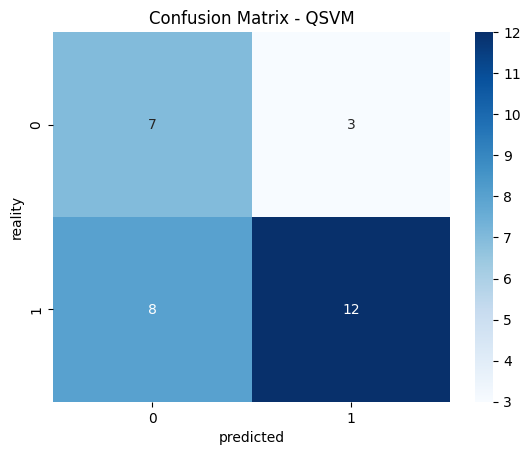

In [9]:
from QSVM import QSVC
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import  train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns
def run_quantum_svm_test(X, y, n_components=4, train_size=100, test_size=30):
   
    print(f"--- ({n_components} Qubits) ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, test_size=test_size, random_state=42, stratify=y
    )


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    minmax = MinMaxScaler(feature_range=(-1,1))
    X_train_final = minmax.fit_transform(X_train_scaled)
    X_test_final = minmax.transform(X_test_scaled)

    
    print("--- Compute Quantum Kernel ---")
    qsvc = QSVC(C=1.0)
    
    qsvc.fit(X_train_final, y_train.values if hasattr(y_train, 'values') else y_train)

    print("--- Testing ---")
    y_pred = qsvc.predict(X_test_final)
    print("\n=== RESULT QSVM ===")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('predicted')
    plt.ylabel('reality')
    plt.title('Confusion Matrix - QSVM')
    plt.show()
    
  
model_q = run_quantum_svm_test(latent_features, new_labels)